C:\Users\enyan\AppData\Local\Temp\ipykernel_26600\3569852948.py:74: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(


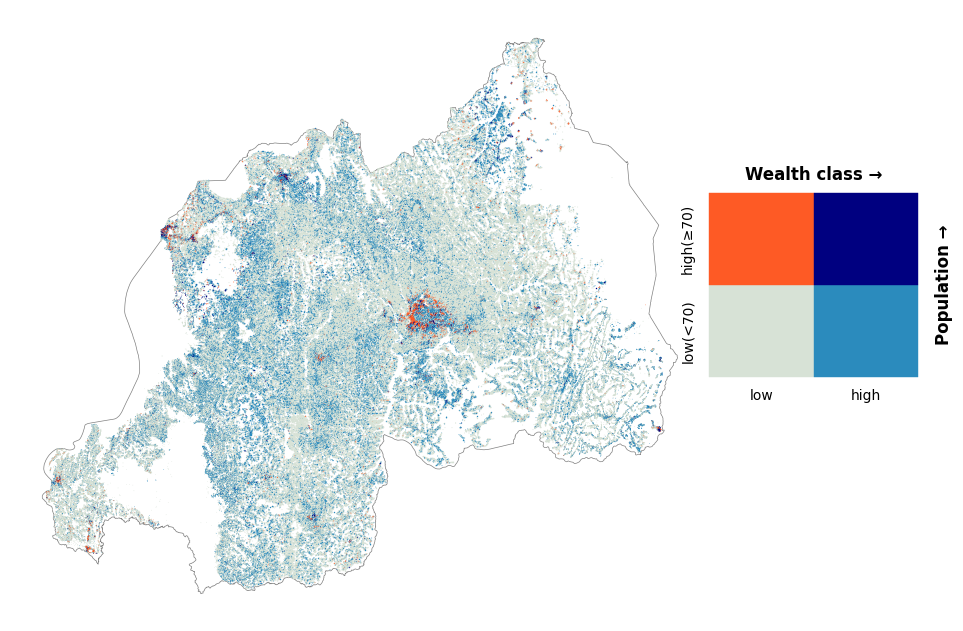

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
import matplotlib.patches as patches
from generativepy.color import Color
from PIL import ImageColor

# === Step 1: Classify data into 2 groups ===
data=gpd.read_file(r"D:\paper3\gridded_village_population_building2gridsWorldPop_village.shp")
b=gpd.read_file('C:/dl/data/country.shp')
if data.crs != b.crs:
    data = data.to_crs(b.crs)
data.rename(columns={
    'POPCELL': 'POPCELL',
}, inplace=True)

data["pop_grp"] = np.where(data["POPCELL"] < 70, 1, 2)      # 1 = low, 2 = high
data["wealth_grp"] = np.where(data["low"] >50, 1, 2)   # 1 = low, 2 = high

# === Step 2: Set number of groups ===
num_grps = 2  # 2 population classes × 2 wealth classes = 4 color combinations

# === Step 3: Define corner colors and interpolate ===
def hex_to_Color(hexcode):
    r, g, b = ImageColor.getcolor(hexcode, "RGB")
    return Color(r / 256, g / 256, b / 256)

# Bivariate corner colors
c00 = hex_to_Color("#d8e3d7")  # Light Gray Green
c10 = hex_to_Color("#FF5A25")  # Deep Red (Crimson)
c01 = hex_to_Color("#2b8cbe")  # Medium Blue (Steel Blue)
c11 = hex_to_Color("#000080")  # Dark Navy Blue

# Interpolate 2x2 color grid
colorlist = []
for i in range(num_grps):
    row_start = c00.lerp(c10, i / (num_grps - 1))
    row_end = c01.lerp(c11, i / (num_grps - 1))
    for j in range(num_grps):
        interp = row_start.lerp(row_end, j / (num_grps - 1))
        colorlist.append(rgb2hex([interp.r, interp.g, interp.b]))

# === Step 4: Assign bivariate color index ===
# Shift classes to 0-based index: 0 or 1
data["bivar_idx"] = (data["pop_grp"] - 1) * num_grps + (data["wealth_grp"] - 1)
data["bivar_color"] = data["bivar_idx"].apply(lambda i: colorlist[i])

# === Step 5: Plot map ===
fig, ax = plt.subplots(figsize=(10, 10))
# Plot background shapefile (light grey, no edges)
b.plot(ax=ax, color="white", edgecolor="grey", linewidth=0.5)
data.plot(
    color=data["bivar_color"],
    edgecolor=data["bivar_color"],
    linewidth=0.2,
    ax=ax
)
#ax.set_title("Bivariate Map: Population vs Wealth", fontsize=16)
ax.axis("off")

# === Step 6: Create legend in bottom-right corner ===
legend_scale = 1.5
legend_size = 10 * legend_scale  # Total legend size
start_x = 1.0  # Moved to right side
start_y = 0.4  # Kept at bottom
pop_labels = ["low(<70)", "high(≥70)"]
wealth_labels = ["low", "high"]

# Draw color grid using interpolated colors
for i in range(num_grps):  # Rows (population)
    for j in range(num_grps):  # Columns (wealth class)
        idx = i * num_grps + j
        rect = patches.Rectangle(
            (start_x + j * legend_size * 0.01, start_y + i * legend_size * 0.01),
            width=legend_size * 0.01,
            height=legend_size * 0.01,
            transform=ax.transAxes,
            color=colorlist[idx],
            edgecolor='black',
            linewidth=0.3,
            clip_on=False
        )
        ax.add_patch(rect)

# Add axis titles
mid = num_grps // 2
ax.text(start_x + mid * legend_size * 0.01, 
        start_y + (num_grps + 0.1) * legend_size * 0.01,
        "Wealth class →", transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12, fontweight='bold')

ax.text(start_x + 0.35, 
        start_y + mid * legend_size * 0.01,
        "Population →", transform=ax.transAxes,
        ha="right", va="center", fontsize=12, rotation=90, fontweight='bold')

# Add bin labels
# Wealth class labels (below the grid)
for j, lbl in enumerate(wealth_labels):
    ax.text(start_x + j * legend_size * 0.01 + legend_size * 0.005,
            start_y - 0.02, lbl,
            transform=ax.transAxes, ha="center", va="top", fontsize=10)

# Population labels (left of the grid) - Natural order
for i, lbl in enumerate(pop_labels):
    ax.text(start_x - 0.02,
            start_y + i * legend_size * 0.01 + legend_size * 0.005,
            lbl, transform=ax.transAxes, ha="right", va="center", rotation=90, fontsize=10)

plt.tight_layout()
#plt.savefig('D:/paper3/Bivariatepopulation_wealth_Rwanda_building2grids_village.jpg', dpi=1200)
plt.show()

In [3]:
#For each city, we estimate the proportion of the population across visibly assessed housing wealth classes. 
#Given that Rwanda's secondary cities are at an early stage of urban development, 
#several remain small in scale.
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import rgb2hex
import matplotlib.patches as patches
from generativepy.color import Color
from PIL import ImageColor

# --- Load shapefiles ---
b = gpd.read_file('C:/dl/data/country.shp')
cities = gpd.read_file(r"D:/paper3/city.shp")
#data = gpd.read_file(r"D:\paper3\gridded_village_population_building2gridsPOPCORN_VILLAGE.shp")
data = gpd.read_file(r"D:\paper3\gridded_village_population_building2gridsWorldPop_village.shp")
if b.crs != data.crs:
    data = data.to_crs(b.crs)
# Create a population proxy column for data
data['density'] = data['POPCELL']


Processing: country



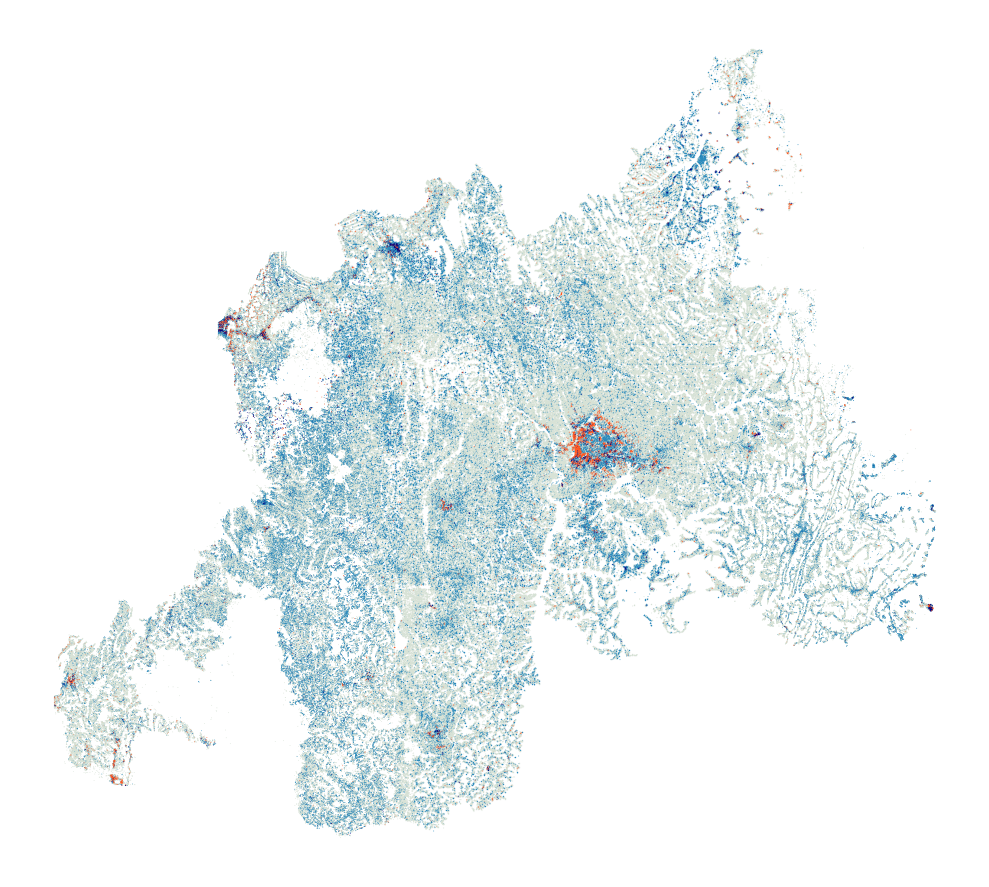

Total lwpop: 8953858.77 (67.61%)
Total hwpop: 4289208.68 (32.39%)
Combined total: 13243067.46
Saved stats → D:/paper3/stats1/country_villages_stats.xlsx

Processing: Kigali



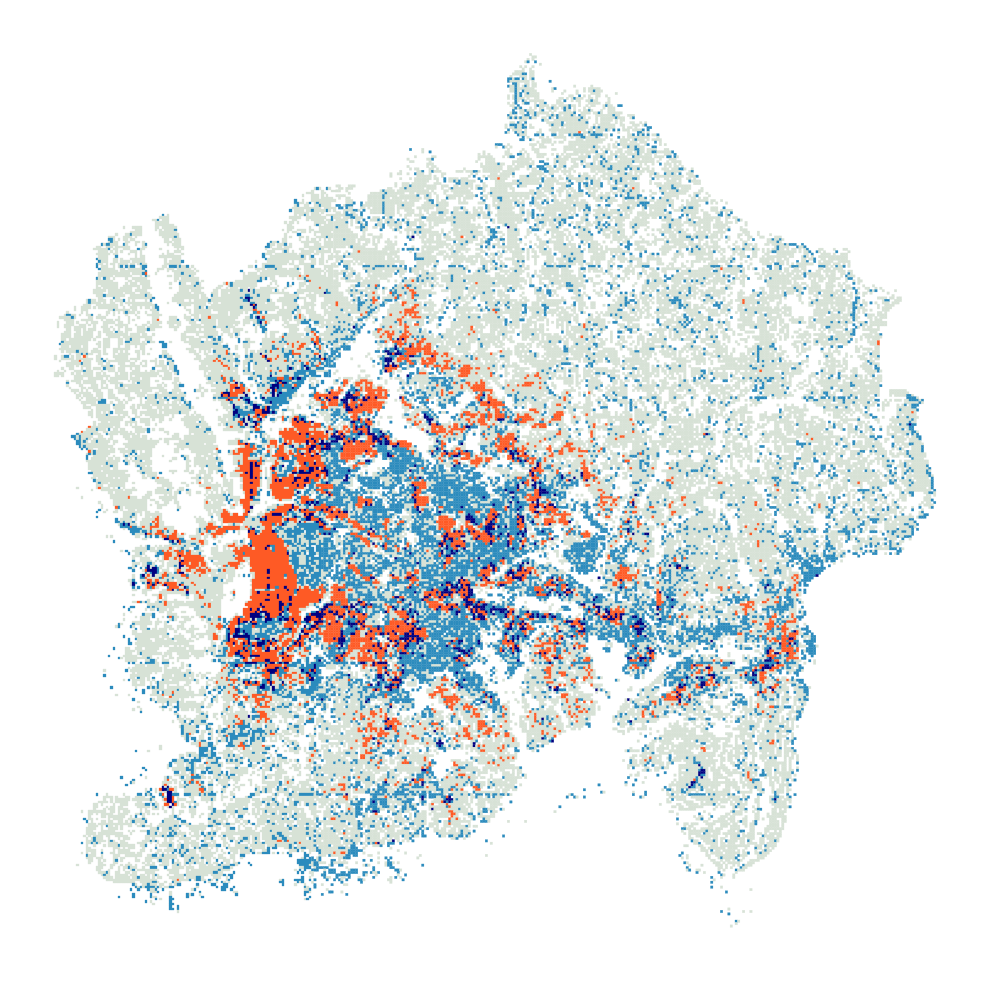

Total lwpop: 1183483.55 (67.76%)
Total hwpop: 563103.82 (32.24%)
Combined total: 1746587.37
Saved stats → D:/paper3/stats1/Kigali_villages_stats.xlsx

Processing: Bugesera



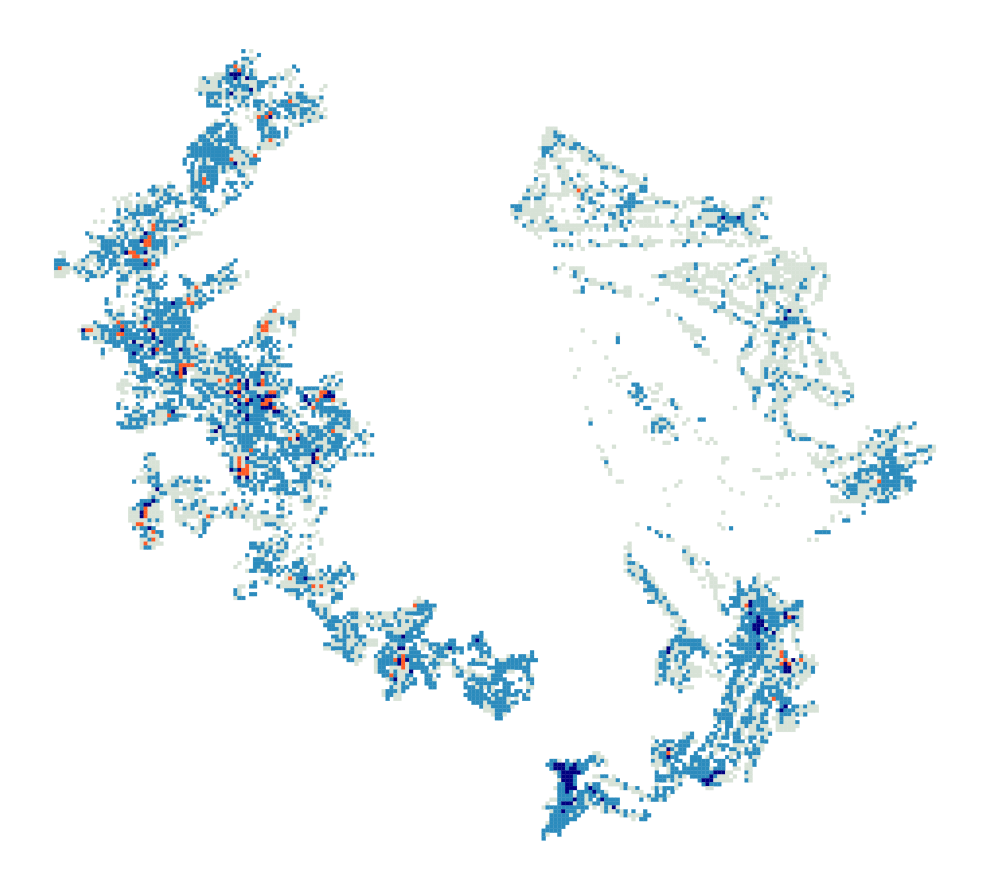

Total lwpop: 75097.78 (49.14%)
Total hwpop: 77718.83 (50.86%)
Combined total: 152816.61
Saved stats → D:/paper3/stats1/Bugesera_villages_stats.xlsx

Processing: Rwamagana



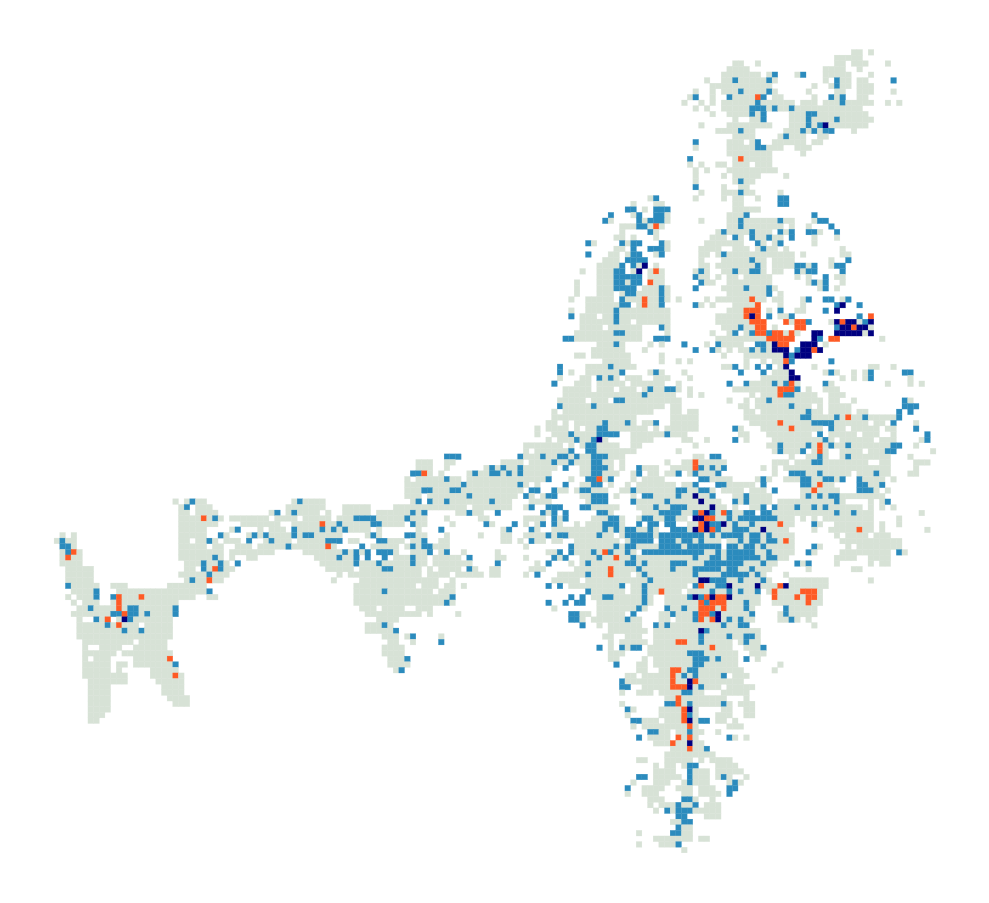

Total lwpop: 78519.28 (65.92%)
Total hwpop: 40589.71 (34.08%)
Combined total: 119108.99
Saved stats → D:/paper3/stats1/Rwamagana_villages_stats.xlsx

Processing: Muhanga



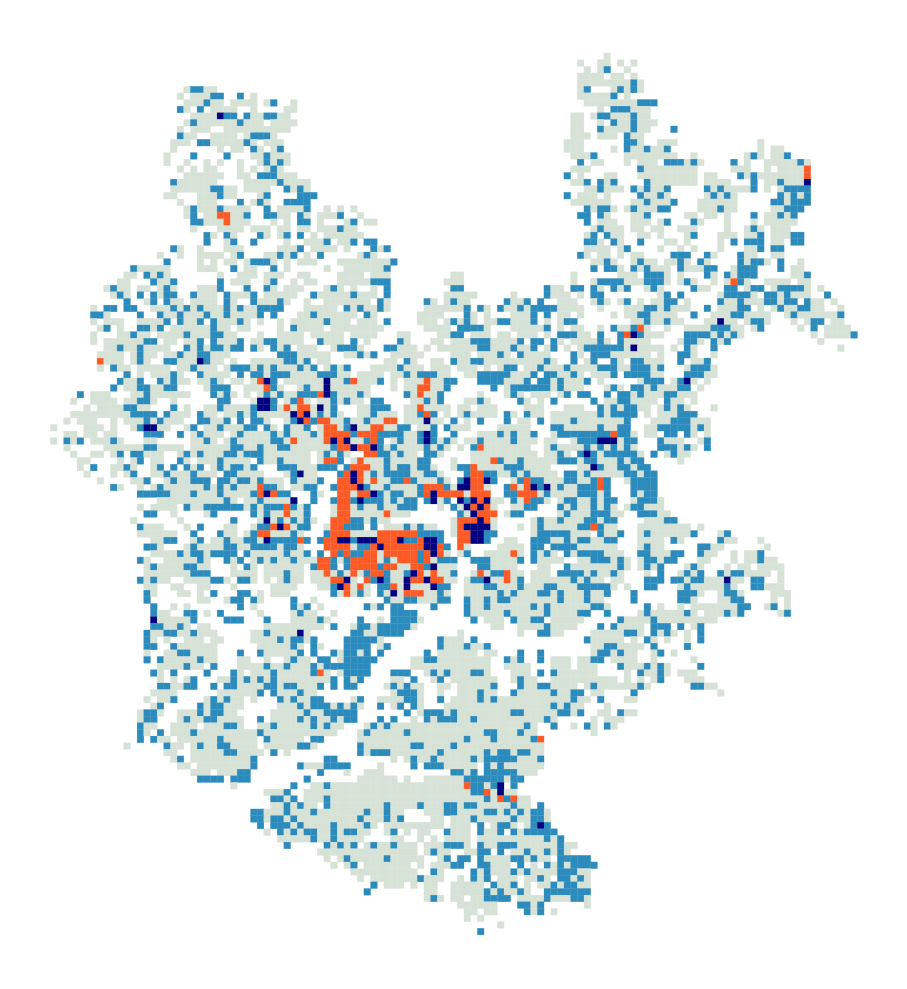

Total lwpop: 73534.21 (57.92%)
Total hwpop: 53415.97 (42.08%)
Combined total: 126950.19
Saved stats → D:/paper3/stats1/Muhanga_villages_stats.xlsx

Processing: Musanze



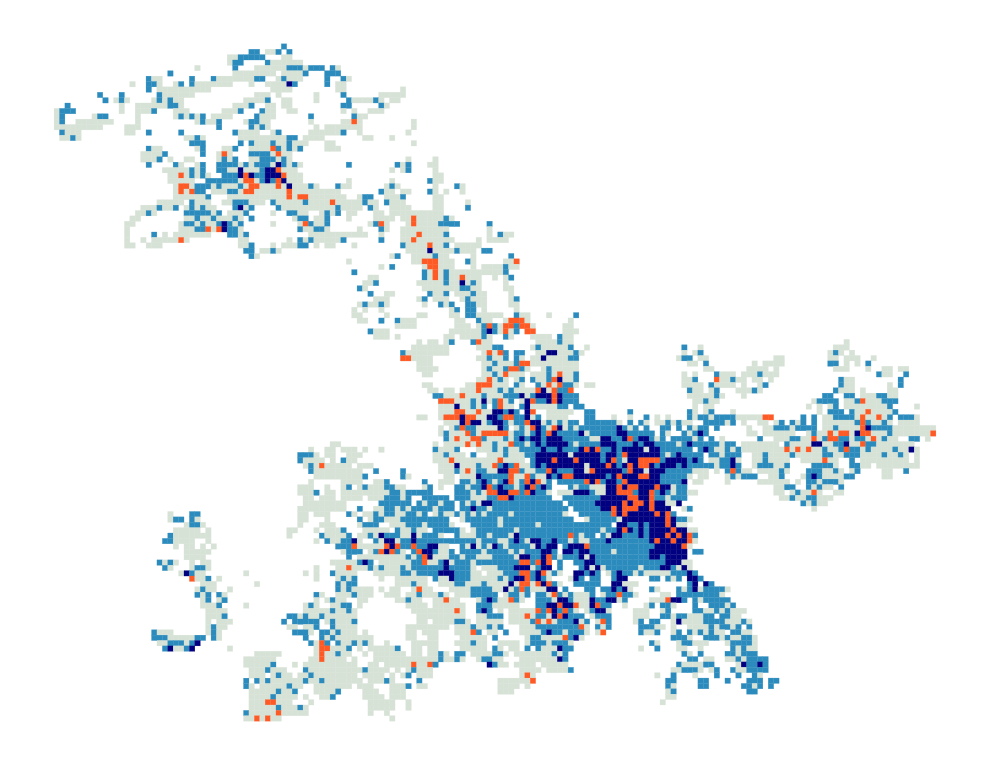

Total lwpop: 95768.58 (53.68%)
Total hwpop: 82637.38 (46.32%)
Combined total: 178405.96
Saved stats → D:/paper3/stats1/Musanze_villages_stats.xlsx

Processing: Rubavu



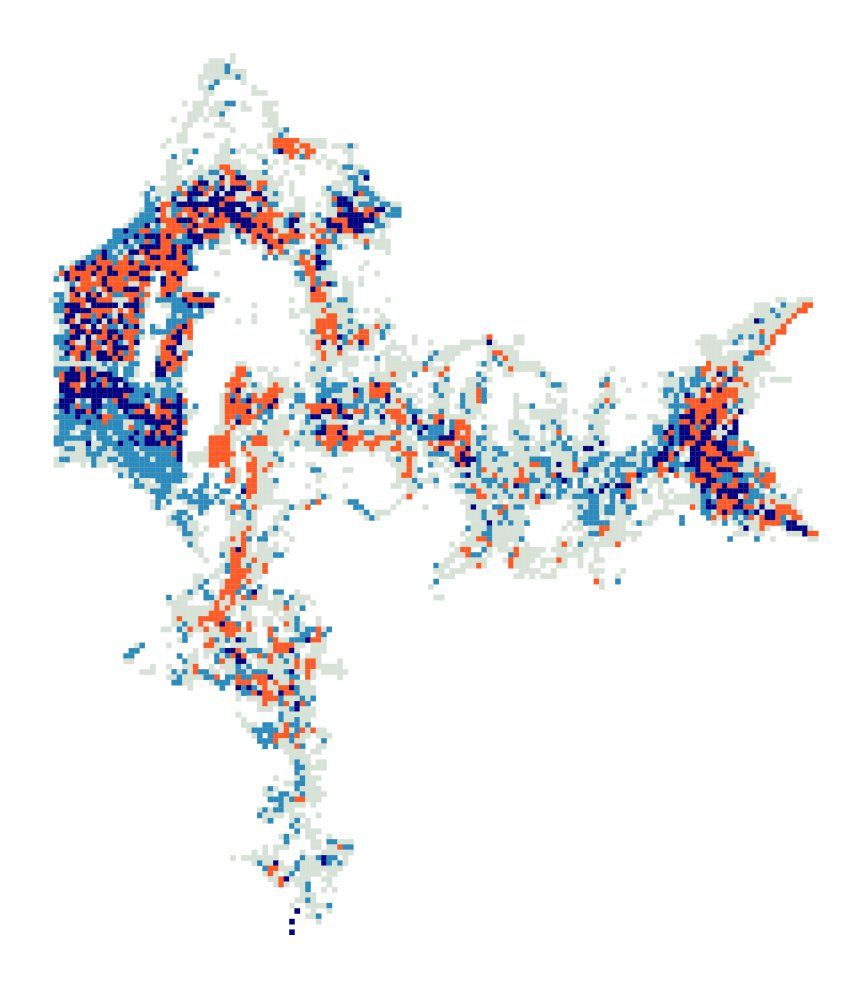

Total lwpop: 165982.74 (58.22%)
Total hwpop: 119105.11 (41.78%)
Combined total: 285087.86
Saved stats → D:/paper3/stats1/Rubavu_villages_stats.xlsx

Processing: Rusizi



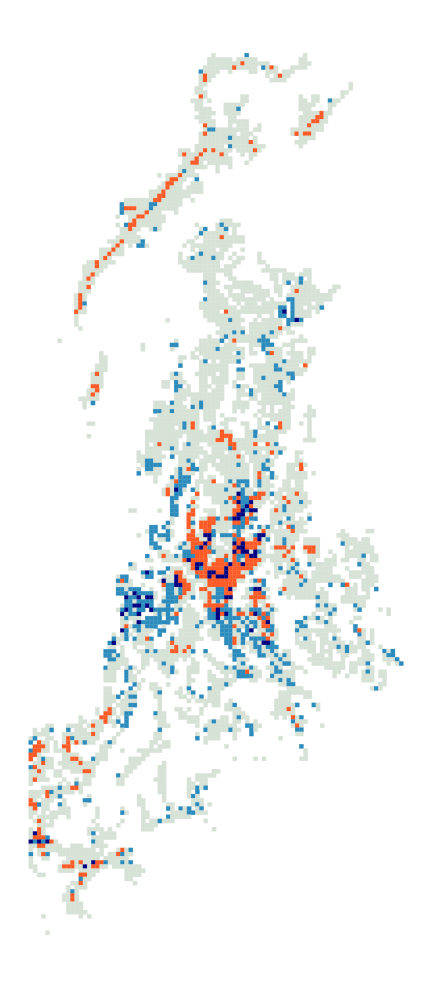

Total lwpop: 104460.88 (73.54%)
Total hwpop: 37594.56 (26.46%)
Combined total: 142055.43
Saved stats → D:/paper3/stats1/Rusizi_villages_stats.xlsx

Processing: Karongi



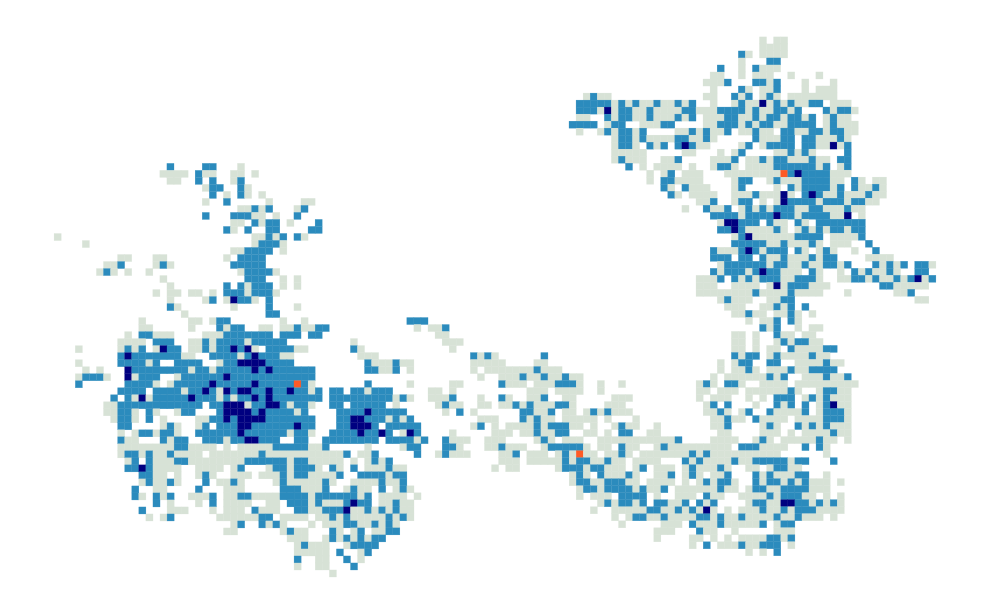

Total lwpop: 23760.87 (47.80%)
Total hwpop: 25944.89 (52.20%)
Combined total: 49705.76
Saved stats → D:/paper3/stats1/Karongi_villages_stats.xlsx

Processing: Huye



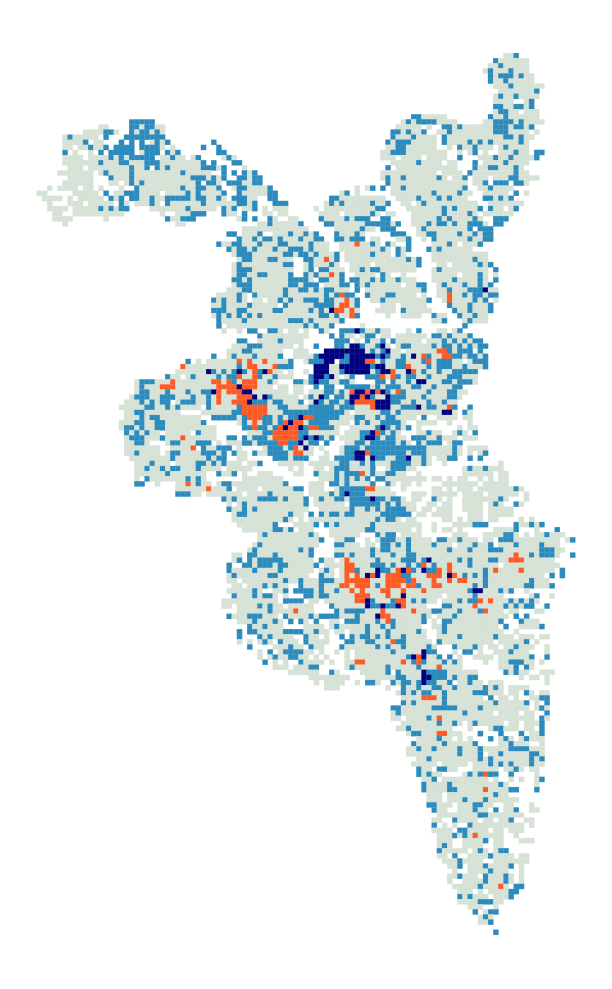

Total lwpop: 75879.90 (58.21%)
Total hwpop: 54465.30 (41.79%)
Combined total: 130345.20
Saved stats → D:/paper3/stats1/Huye_villages_stats.xlsx

Processing: Kirehe



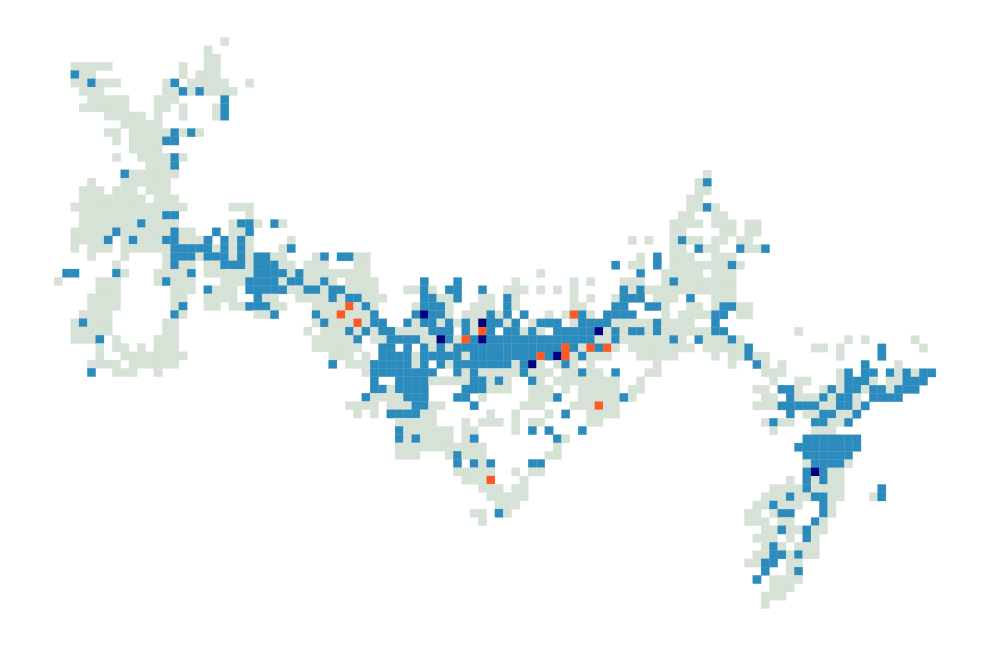

Total lwpop: 16801.15 (61.88%)
Total hwpop: 10350.06 (38.12%)
Combined total: 27151.21
Saved stats → D:/paper3/stats1/Kirehe_villages_stats.xlsx

Processing: Kayonza



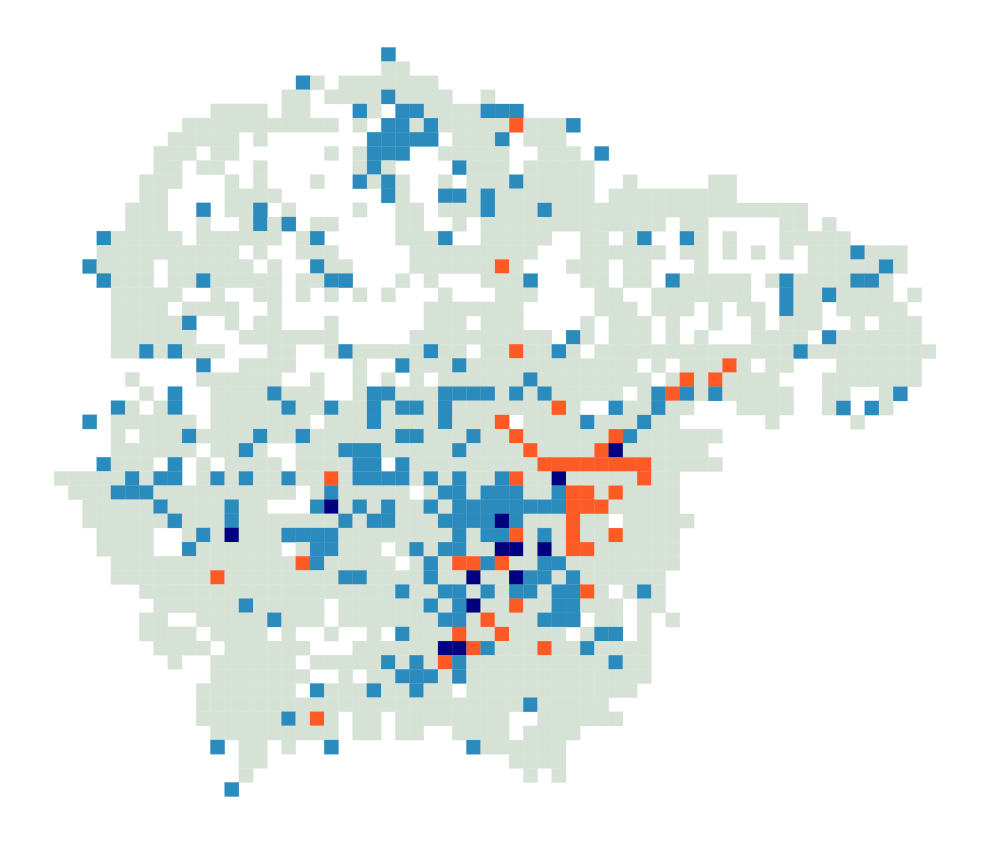

Total lwpop: 27537.99 (71.77%)
Total hwpop: 10834.23 (28.23%)
Combined total: 38372.22
Saved stats → D:/paper3/stats1/Kayonza_villages_stats.xlsx

Processing: Nyagatare



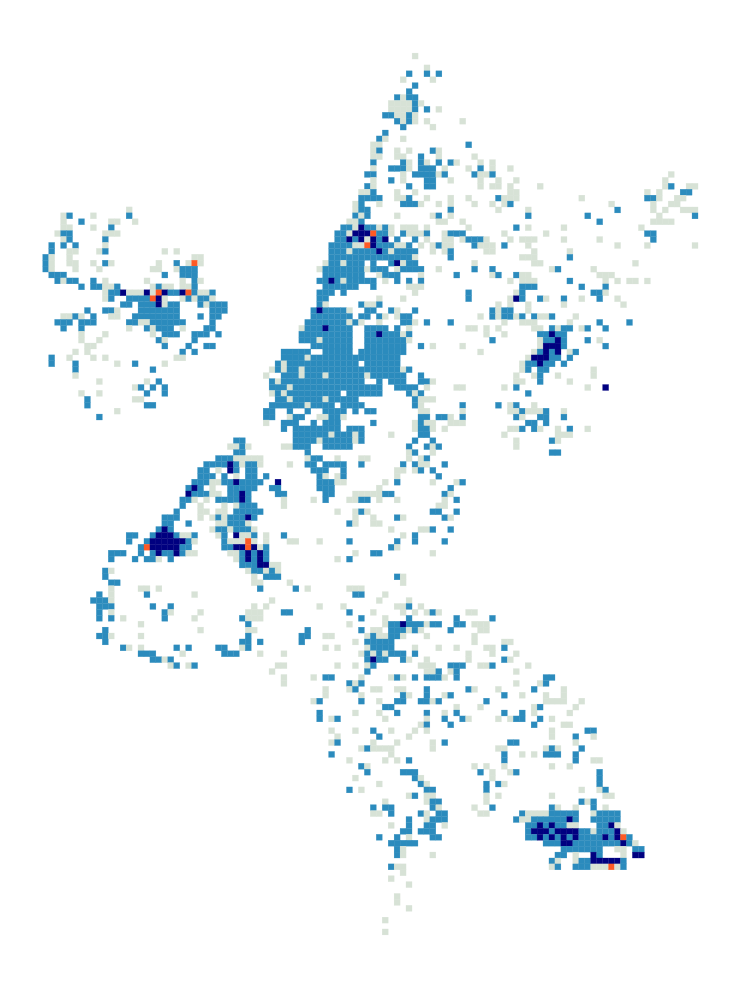

Total lwpop: 15891.00 (35.85%)
Total hwpop: 28434.18 (64.15%)
Combined total: 44325.18
Saved stats → D:/paper3/stats1/Nyagatare_villages_stats.xlsx


In [4]:
names = ['country', 'Kigali', 'Bugesera','Rwamagana', 'Muhanga', 'Musanze','Rubavu', 'Rusizi', 'Karongi','Huye', 'Kirehe', 'Kayonza', 'Nyagatare']   # <- your list of countries or cities
for name in names:
    print(f"\n==============================")
    print(f"Processing: {name}")
    print(f"==============================\n")

    # Load city boundary
    city = gpd.read_file(f"D:/paper3/{name}.shp")

    # Ensure CRS match
    grids = data.to_crs(city.crs)

    # Compute centroids
    grids['centroid'] = grids.geometry.centroid
    centroids = gpd.GeoDataFrame(grids[['centroid']], geometry='centroid', crs=grids.crs)

    # Spatial join → keep only grids inside city
    grids_in_city = gpd.sjoin(grids, city, how='inner', predicate='intersects')
    data_city = grids_in_city.drop(columns=['index_right'])

    # --- Population calculations ---
    total_lwpop = (data_city['POPCELL'] * data_city['low'] / 100).sum()
    total_hwpop = (data_city['POPCELL'] * data_city['high'] / 100).sum()
    combined_total = total_lwpop + total_hwpop

    lwpop_pct = (total_lwpop / combined_total) * 100
    hwpop_pct = (total_hwpop / combined_total) * 100

    # --- Classification ---
    data_city["pop_grp"] = np.where(data_city["POPCELL"] < 70, 1, 2)
    data_city["wealth_grp"] = np.where(data_city["low"] > 50, 1, 2)

    # --- Color interpolation ---
    num_grps = 2

    def hex_to_Color(hexcode):
        r, g, b = ImageColor.getcolor(hexcode, "RGB")
        return Color(r / 256, g / 256, b / 256)

    c00 = hex_to_Color("#d8e3d7")
    c10 = hex_to_Color("#FF5A25")
    c01 = hex_to_Color("#2b8cbe")
    c11 = hex_to_Color("#000080")

    colorlist = []
    for i in range(num_grps):
        row_start = c00.lerp(c10, i / (num_grps - 1))
        row_end = c01.lerp(c11, i / (num_grps - 1))
        for j in range(num_grps):
            interp = row_start.lerp(row_end, j / (num_grps - 1))
            colorlist.append(rgb2hex([interp.r, interp.g, interp.b]))

    data_city["bivar_idx"] = (data_city["pop_grp"] - 1) * num_grps + (data_city["wealth_grp"] - 1)
    data_city["bivar_color"] = data_city["bivar_idx"].apply(lambda i: colorlist[i])

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 10))
    data_city.plot(
        color=data_city["bivar_color"],
        edgecolor=data_city["bivar_color"],
        linewidth=0.2,
        ax=ax
    )
    ax.axis("off")
    plt.tight_layout()
    #plt.savefig(f"D:/paper3/images1/Bivariate_{name}.jpg", dpi=1200)
    plt.show()

    # --- Stats ---
    bivar_labels = {
        0: "LPLW",
        1: "LPHW",
        2: "HPLW",
        3: "HPHW"
    }

    data_city["bivar_class"] = data_city["bivar_idx"].map(bivar_labels)

    stats = data_city.groupby("bivar_class").agg(
        count=('bivar_class', 'count'),
        sum_pop=('POPCELL', 'sum'),
        mean_pop=('POPCELL', 'mean'),
        median_pop=('POPCELL', 'median')
    ).reset_index()

    total_count = stats['count'].sum()
    stats['percent'] = stats['count'] / total_count * 100

    stats = stats.round({'sum_pop': 2, 'mean_pop': 2, 'median_pop': 2, 'percent': 2})

    #stats.to_excel(f"D:/paper3/stats1/{name}_villages_stats.xlsx", index=False)

    print(f"Total lwpop: {total_lwpop:.2f} ({lwpop_pct:.2f}%)")
    print(f"Total hwpop: {total_hwpop:.2f} ({hwpop_pct:.2f}%)")
    print(f"Combined total: {combined_total:.2f}")
    print(f"Saved stats → D:/paper3/stats1/{name}_villages_stats.xlsx")


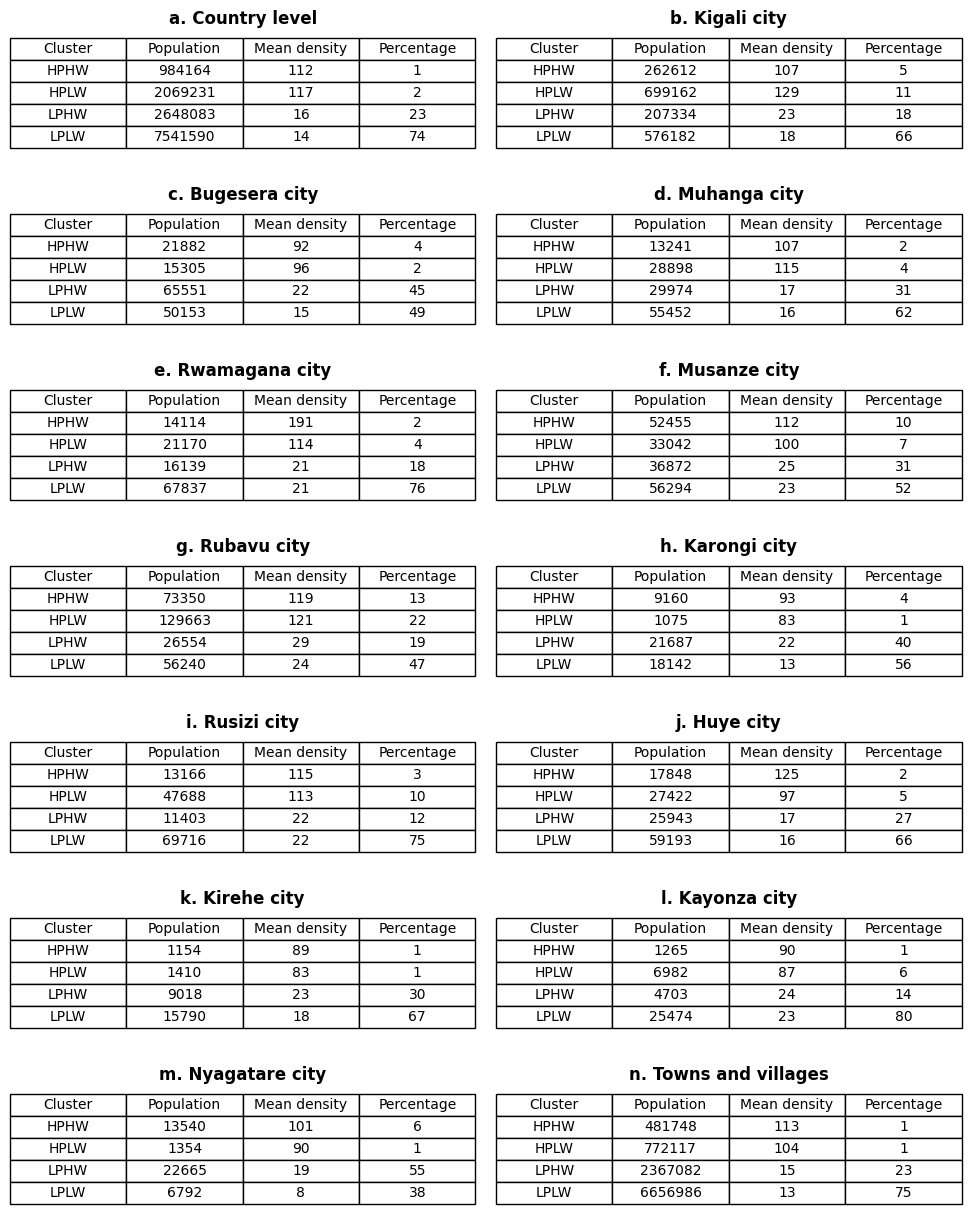

In [2]:
##The generated Excel datasets are subsequently used to derive city-level statistical estimates.
#The resulting estimates provide a robust empirical basis for evaluating the performance of the current spatial planning framework across cities.
#These findings also identify critical shortcomings that warrant policy attention. Given the scarcity and strategic importance of land in Rwanda,
#improving the effectiveness of spatial planning is essential for promoting sustainable, equitable, and efficient land management

import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Folder with Excel files
files = glob.glob("D:/paper3/stat1/*.xlsx")

# Layout: 3 columns
ncols = 2
nrows = -(-len(files) // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, nrows * 1.8))
axes = axes.flatten()

for ax, file in zip(axes, files):
    # Load data
    df = pd.read_excel(file)

    # Drop unnecessary columns
    df = df.drop(columns=["count", "median_pop"])

    # Rename columns
    df = df.rename(columns={
        "bivar_class": "Cluster",
        "sum_pop": "Population",
        "mean_pop": "Mean density",
        "percent": "Percentage"
    })
    df = df.round(0)
    df = df.astype({col: "int64" for col in df.select_dtypes(include="number").columns})
    # Plot as table
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    # Title = filename
    title = os.path.basename(file).replace(".xlsx", "")
    ax.set_title(title, fontsize=12, weight="bold", pad=3)

# Hide unused axes
for ax in axes[len(files):]:
    ax.axis("off")

plt.tight_layout(pad=2.0)
plt.savefig('D:/paper3/clustering_village_decimalremoved.png', dpi=1200)
plt.show()



     POPCELL                city
0   2.389251  Towns and villages
1   8.469333  Towns and villages
2  13.302761  Towns and villages
3   9.924854  Towns and villages
4   2.059699  Towns and villages


C:\Users\enyan\AppData\Local\Temp\ipykernel_26600\4084309798.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 5)  # 4 levels
C:\Users\enyan\AppData\Local\Temp\ipykernel_26600\4084309798.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


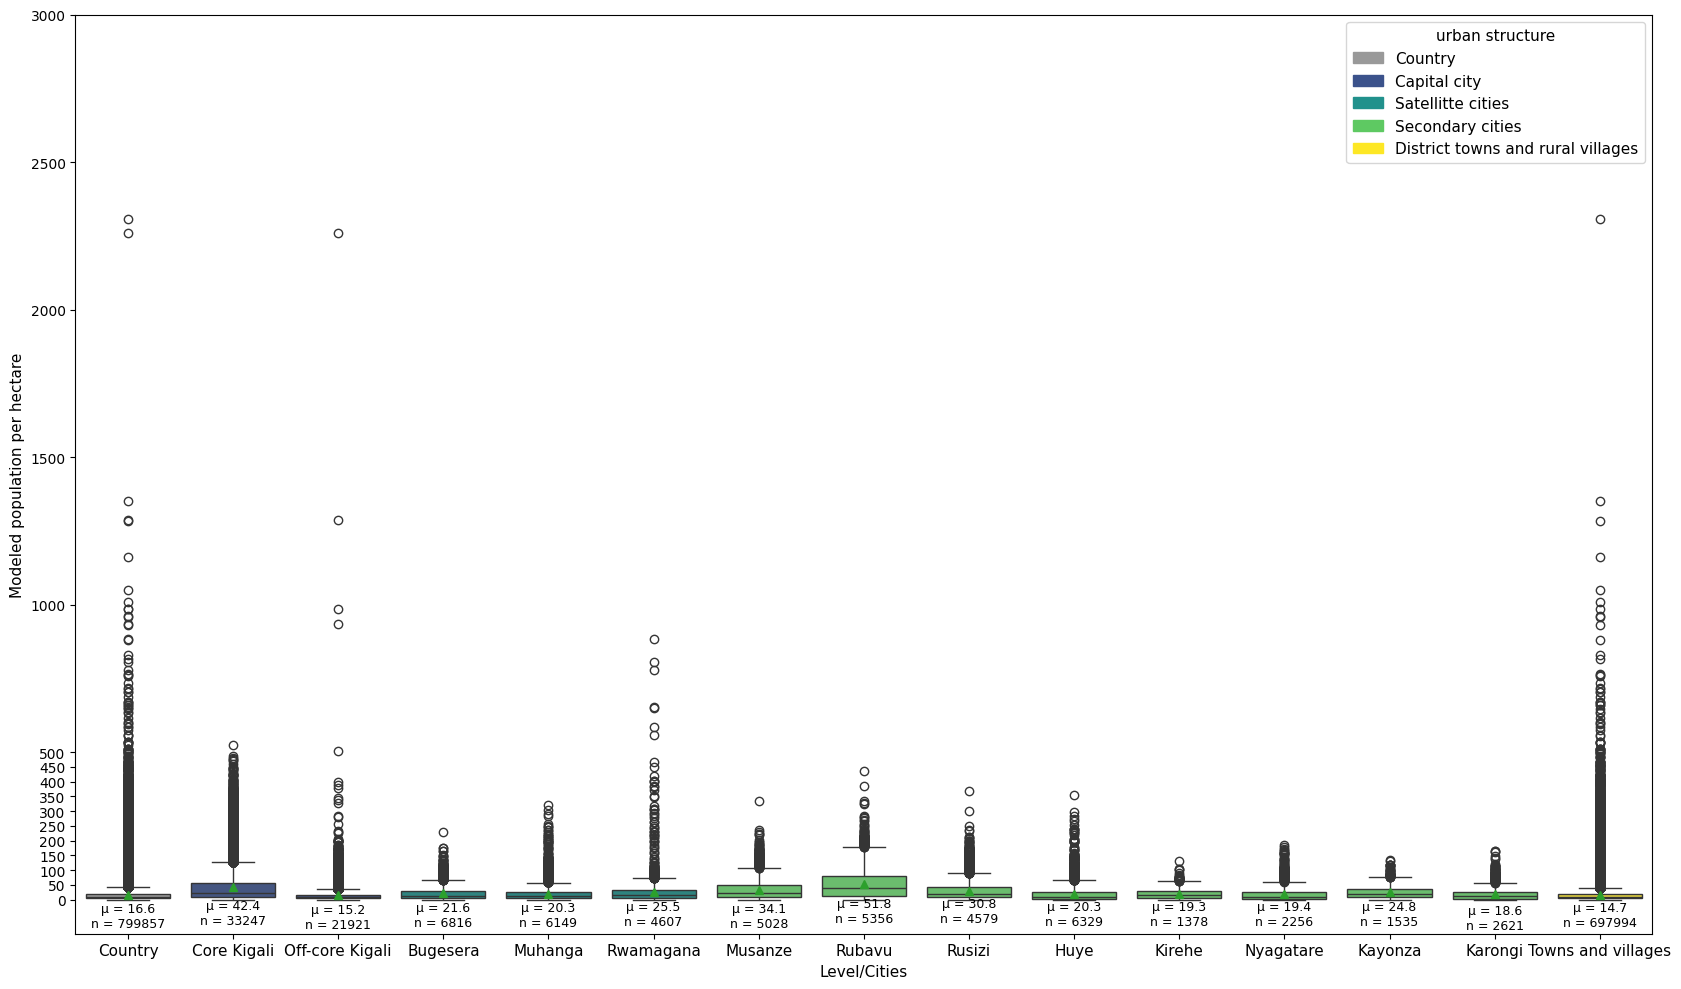

In [5]:
import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

# Load shapefiles

gdf_cities = gpd.read_file("D:/paper3/cities.shp")

# Ensure same CRS
data = data.to_crs(gdf_cities.crs)
# Compute centroid for each grid
data['centroid'] = data.geometry.centroid

# Create GeoDataFrame of centroids
gdf_points = gpd.GeoDataFrame(
    data[['POPCELL']],    # keep density or other attributes
    geometry=data['centroid'],
    crs=data.crs
)
# Assign city to each point using 'within'
gdf_points = gpd.sjoin(
    gdf_points,
    gdf_cities[['city', 'geometry']],
    how='left',
    predicate='within'
)

# Check result
print(gdf_points[['POPCELL', 'city']].head())

# --- Data prep ---
df = gdf_points[['POPCELL', 'city']].dropna()
df_country = pd.DataFrame({'POPCELL': gdf_points['POPCELL'], 'city': ['Country']*len(gdf_points)})
df_all = pd.concat([df, df_country], ignore_index=True)

stats = df_all.groupby('city').agg(
    mean_val=('POPCELL','mean'),
    n_val=('POPCELL','count')
).reset_index()

# --- Hierarchy ---
hierarchy = {
    0: ['Country'],
    1: ['Core Kigali','Off-core Kigali'],
    2: ['Bugesera', 'Muhanga', 'Rwamagana'],
    3: ['Musanze', 'Rubavu', 'Rusizi', 'Huye', 'Kirehe', 'Nyagatare', 'Kayonza', 'Karongi'],
    4:['Towns and villages']
}

# Build plotting order following hierarchy
order = []
for level in [0, 1, 2, 3, 4]:
    order.extend(hierarchy[level])

# --- Build gradient colors ---
cmap = cm.get_cmap("viridis", 5)  # 4 levels
palette = {}

for level, cities in hierarchy.items():
    color = mcolors.to_hex(cmap(level)) if level > 0 else "#999999"  # grey for Country
    for c in cities:
        palette[c] = color

# --- Plot ---
plt.figure(figsize=(17,10))
ax = sns.boxplot(
    x='city', y='POPCELL', data=df_all,
    palette=palette, showmeans=True, order=order
)

# Define custom vertical offsets per city
y_offsets = {
    'Country': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Core Kigali': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.059),
    'Off-core Kigali': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Bugesera': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Muhanga': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Rwamagana': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Musanze': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.06),
    'Rubavu': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.06),
    'Rusizi': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.05),
    'Huye': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.05),
    'Kirehe': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.05),
    'Nyagatare': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.05),
    'Kayonza': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.052),
    'Karongi': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.055),
    'Towns and villages': (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * (-0.05)
}

# Add mean and n labels with custom offsets
for i, city in enumerate(order):
    row = stats.loc[stats['city'] == city]
    if not row.empty:
        mean_val = row['mean_val'].values[0]
        n_val = row['n_val'].values[0]
        offset = y_offsets.get(city, (df_all['POPCELL'].max() - df_all['POPCELL'].min()) * 0.03)  # default if missing
        ax.text(i, mean_val + offset, f"μ = {mean_val:.1f}\nn = {n_val}",
                ha='center', va='bottom', fontsize=9, color='black')

# --- Build custom legend ---
legend_patches = [
    mpatches.Patch(color="#999999", label="Country"),
    mpatches.Patch(color=mcolors.to_hex(cmap(1)), label="Capital city"),
    mpatches.Patch(color=mcolors.to_hex(cmap(2)), label="Satellitte cities"),
    mpatches.Patch(color=mcolors.to_hex(cmap(3)), label="Secondary cities"),
    mpatches.Patch(color=mcolors.to_hex(cmap(4)), label="District towns and rural villages")
]

plt.legend(handles=legend_patches, title="urban structure", loc='upper right', fontsize=11, title_fontsize=11, frameon=True)
# --- Custom Y-ticks ---
yticks = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 1000, 1500, 2000, 2500, 3000]
ax.set_yticks(yticks)
# --- Axis formatting ---
plt.xticks(rotation=0, fontsize=11)
plt.ylabel('Modeled population per hectare', fontsize=11)
plt.xlabel('Level/Cities', fontsize=11)
#plt.title('Density Distribution by City and Country', fontsize=14)
plt.tight_layout()
#plt.savefig('D:/paper3/boxplotdensity_village.jpg', dpi=1200)
plt.show()
